In [24]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print(torch.__version__)

2.8.0+cu129


In [25]:
#create data
weigth=0.7
bias=0.3
X=torch.arange(0,1,0.02).unsqueeze(dim=1)
Y=weigth*X+bias
X[:10],Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [26]:
#train test split
train_split=int(0.8*len(X))
x_train,y_train=X[:train_split],Y[:train_split]
x_test,y_test=X[train_split:],Y[train_split:]

len(x_train),len(x_test),len(y_train),len(y_test)

(40, 10, 40, 10)

In [27]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    #plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    #plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        #plot predictions in red
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    
    plt.legend(prop={"size": 14});

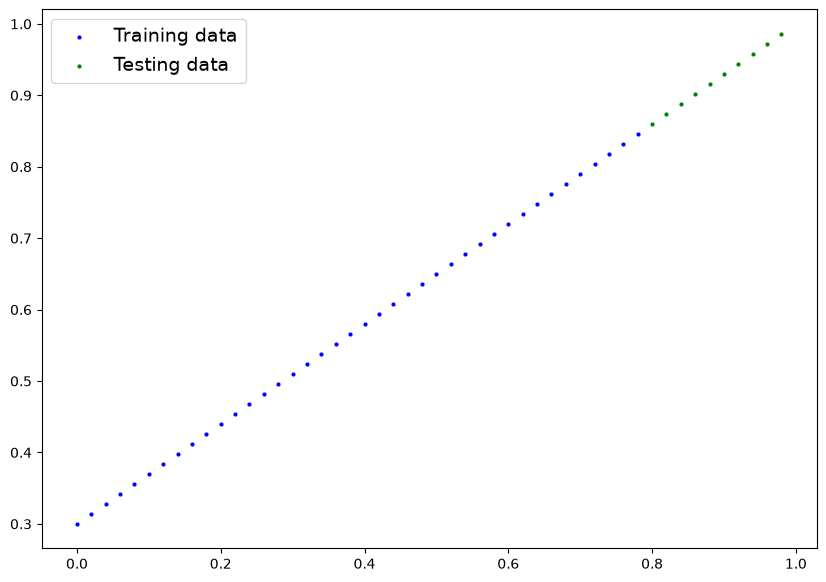

In [28]:
plot_predictions()

In [29]:
class  LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights*x+self.bias

In [30]:
torch.manual_seed(42)
model_0=LinearRegressionModel()  #object creation
list(model_0.parameters()) 

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

# parent class nn.Module contains many methos like
model_0.parameters()

model_0.state_dict()

model_0.train()

model_0.eval()

model_0.to(device)

model_0.named_parameters()

In [31]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

| Code                           | Meaning                                                                                           |
| ------------------------------ | ------------------------------------------------------------------------------------------------- |
| `with torch.inference_mode():` | Temporarily disables gradient tracking to make prediction faster and use less memory.             |
| `model_0(X_test)`              | Calls the model object. Internally this invokes `forward(X_test)` through `nn.Module.__call__()`. |
| `forward()`                    | Computes the prediction using the model's equation (`weights * x + bias` in your case).           |
| `y_preds`                      | Stores the predicted output tensor returned by the model.                                         |


In [32]:
with torch.inference_mode(): 
    y_preds = model_0(x_test)

In [33]:
# Check the predictions
print(f"Number of testing samples: {len(x_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


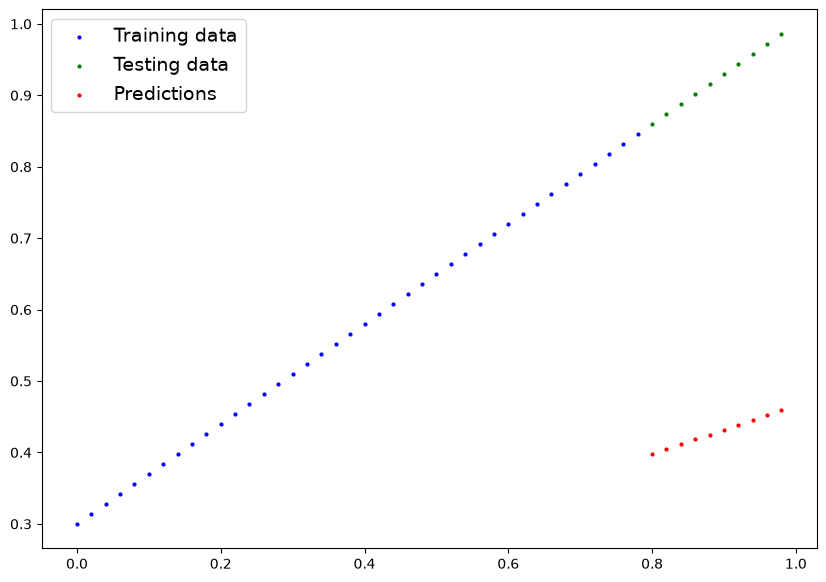

In [34]:
plot_predictions(predictions=y_preds)

Train Model

In [35]:
loss_fn=nn.L1Loss()#mean absolute error


optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)


In [36]:
torch.manual_seed(42)

epoch=100

train_loss_values=[]
test_loss_values=[]
epoch_counts=[]

for epoch in range(epoch):
    #training
    model_0.train()
    y_pred=model_0(x_train)
    loss=loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #testing
    model_0.eval()
    with torch.inference_mode(): #important to use inference mode while testing
        '''✅ Doesn't track gradients
           ✅ Doesn't build the computation graph
           ✅ Uses less memory
           ✅ Runs faster'''
        test_pred=model_0(x_test)
        test_loss=loss_fn(test_pred,y_test)

    if epoch%10==0:
            epoch_counts.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch:{epoch} | Train loss:{loss} | Test loss:{test_loss}")




Epoch:0 | Train loss:0.31288138031959534 | Test loss:0.48106518387794495
Epoch:10 | Train loss:0.1976713240146637 | Test loss:0.3463551998138428
Epoch:20 | Train loss:0.08908725529909134 | Test loss:0.21729660034179688
Epoch:30 | Train loss:0.053148526698350906 | Test loss:0.14464017748832703
Epoch:40 | Train loss:0.04543796554207802 | Test loss:0.11360953003168106
Epoch:50 | Train loss:0.04167863354086876 | Test loss:0.09919948130846024
Epoch:60 | Train loss:0.03818932920694351 | Test loss:0.08886633068323135
Epoch:70 | Train loss:0.03476089984178543 | Test loss:0.0805937647819519
Epoch:80 | Train loss:0.03132382780313492 | Test loss:0.07232122868299484
Epoch:90 | Train loss:0.02788739837706089 | Test loss:0.06473556160926819


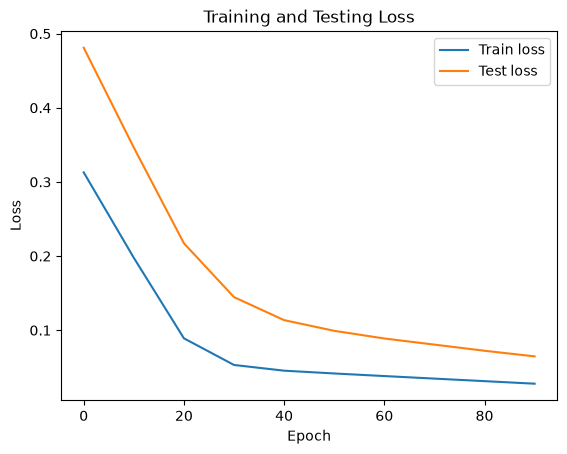

In [37]:
plt.plot(epoch_counts,train_loss_values,label="Train loss")
plt.plot(epoch_counts,test_loss_values,label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()

In [38]:
'''print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weight: {weight}, bias: {bias}")'''

'print("The model learned the following values for weights and bias:")\nprint(model_0.state_dict())\nprint("\nAnd the original values for weights and bias are:")\nprint(f"weight: {weight}, bias: {bias}")'

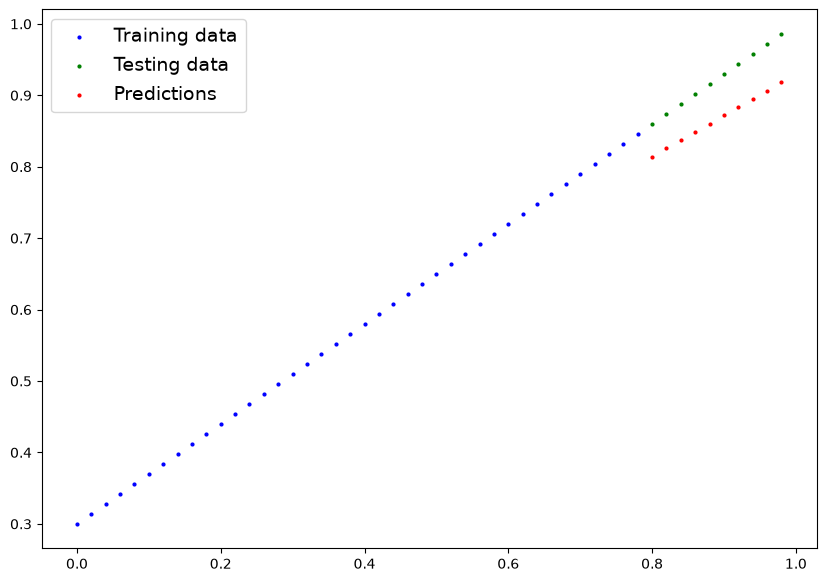

In [39]:
plot_predictions(predictions=test_pred)

In [40]:
# how to save
from pathlib import Path

Model_Path=Path("models")
Model_Path.mkdir(parents=True,exist_ok=True) #"Create the models folder. If it already exists, that's fine."

Model_Name="01_pytorch_workflow_model_0.pth"
Model_save_path=Model_Path/Model_Name

print(f"Saving model to: {Model_save_path}")
torch.save(obj=model_0.state_dict(), # state_dict() contains the model's learned parameters (weights and bias)
           f=Model_save_path)

Saving model to: models\01_pytorch_workflow_model_0.pth


In [41]:
#Check the saved model
!dir models

 Volume in drive C is OS
 Volume Serial Number is 3804-4B66

 Directory of c:\Users\Prajwal\OneDrive\Desktop\p\models

08/08/2026  08:08 PM    <DIR>          .
08/08/2026  08:08 PM    <DIR>          ..
08/08/2026  08:25 PM             2,117 01_pytorch_workflow_model_0.pth
               1 File(s)          2,117 bytes
               2 Dir(s)  850,629,558,272 bytes free


Loading model

In [42]:
loaded_model_0=LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=Model_save_path))


<All keys matched successfully>

In [43]:
loaded_model_0.eval()

with torch.inference_mode():
    loaded_model_preds=loaded_model_0(x_test)

In [47]:
test_pred==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

Now lets try running it on GPU( before it was on CPU)

In [49]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.8.0+cu129'

In [48]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [50]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias 
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [51]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

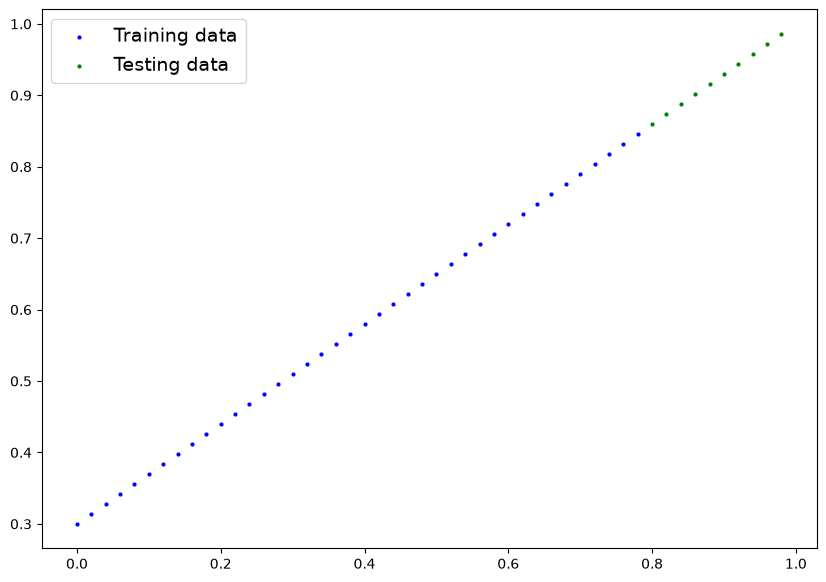

In [52]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

In [53]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, 
                                      out_features=1)
    
    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [54]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [55]:
# Set model to GPU if it's available, otherwise it'll default to CPU
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='cuda', index=0)

In [56]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.01)

In [58]:
torch.manual_seed(42)

# Set the number of epochs 
epochs = 1000 

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)
    
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 100 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 200 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [61]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'linear_layer.weight': tensor([[0.6968]], device='cuda:0'), 'linear_layer.bias': tensor([0.3025], device='cuda:0')})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


In [62]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

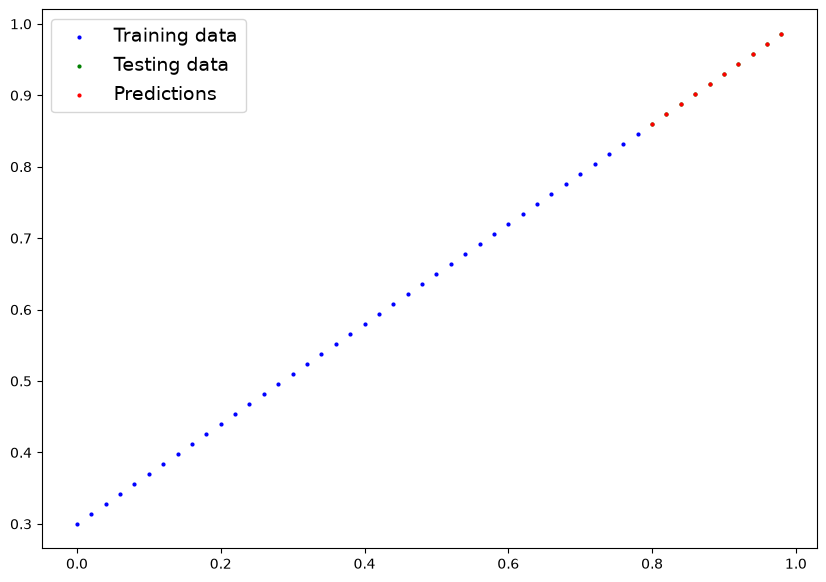

In [63]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())

In [64]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\01_pytorch_workflow_model_1.pth


In [65]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict 
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [66]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')